# Import Necessary Modules

In [307]:
import whisper #https://openai.com/research/whisper
import datetime

import subprocess

import torch
from pyannote.audio.pipelines.speaker_verification import PretrainedSpeakerEmbedding
from pyannote.audio import Audio
from pyannote.core import Segment

import wave
import contextlib

from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.io import wavfile

import matplotlib.pyplot as plt


# Define Few Variables

In [308]:
# speaker_count = 2
speaker_count = 4

language = 'English'
model_size = 'tiny'

# Load Embedding Model

In [309]:
#https://github.com/speechbrain/speechbrain/tree/develop/recipes/VoxCeleb/SpeakerRec
embedding_model = PretrainedSpeakerEmbedding("speechbrain/spkrec-ecapa-voxceleb",device=torch.device("cpu"))

In [310]:
# path = "audio.wav"
path = "../utils/audioFiles/long_audio_files/4_Speaker_5mins.wav"
# path = "mc1.mp3"

In [311]:
if path[-3:] != 'wav':
  subprocess.call(['ffmpeg', '-i', path, 'audio.wav', '-y'])
  
else:
  fs, data = wavfile.read(path)
  try:
    wavfile.write('audio.wav', fs, data[:, 0])
  except:
    wavfile.write('audio.wav', fs, data[:])

path = 'audio.wav'

# Load Whisper Model for Speech to Text

In [312]:
model = whisper.load_model(model_size)#Speech to Text Model
result = model.transcribe(path)
segments = result["segments"]

# Read Audio File

In [313]:
wav_file = wave.open(path,'r')
with contextlib.closing(wav_file) as f:
  frames = f.getnframes()
  rate = f.getframerate()
  duration = frames / float(rate)

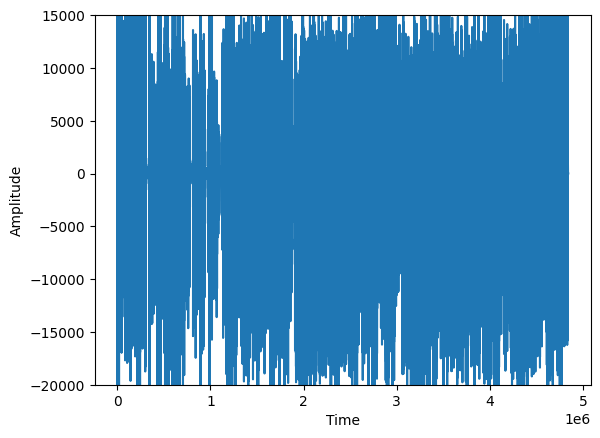

In [314]:
fs, data = wavfile.read(path)
plt.plot(data[0:])
plt.ylim(-20000,15000)
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.show()

# Function to Embed Audio in suitale Type and Size

In [315]:
audio = Audio()

def segment_embedding(segment):
  start = segment["start"]
  # Whisper overshoots the end timestamp in the last segment
  end = min(duration, segment["end"])
  clip = Segment(start, end)
  waveform, sample_rate = audio.crop(path, clip)
  wavform = waveform[None]
  embd_mdl = embedding_model(wavform)
  return embd_mdl

In [316]:
embeddings = np.zeros(shape=(len(segments), 192))

# Get all Segments of Audio

In [317]:

for s_no, segment in enumerate(segments):
  print(s_no, segment)
  embd = segment_embedding(segment)
  embeddings[s_no] = embd

0 {'id': 0, 'seek': 0, 'start': 0.0, 'end': 4.88, 'text': ' Well, several 2020 presidential candidates are coming to the defense of Congresswoman Ilhan Omar.', 'tokens': [50364, 1042, 11, 2940, 4808, 16902, 11255, 366, 1348, 281, 264, 7654, 295, 6426, 18339, 4416, 3451, 33784, 13, 50608], 'temperature': 0.0, 'avg_logprob': -0.31847797393798827, 'compression_ratio': 1.4875444839857652, 'no_speech_prob': 0.014423033222556114}


1 {'id': 1, 'seek': 0, 'start': 4.88, 'end': 10.72, 'text': ' After President Trump tweeted in edited video, what some say is inciting hatred against her.', 'tokens': [50608, 2381, 3117, 3899, 25646, 294, 23016, 960, 11, 437, 512, 584, 307, 834, 1748, 21890, 1970, 720, 13, 50900], 'temperature': 0.0, 'avg_logprob': -0.31847797393798827, 'compression_ratio': 1.4875444839857652, 'no_speech_prob': 0.014423033222556114}
2 {'id': 2, 'seek': 0, 'start': 10.72, 'end': 12.72, 'text': " Now, here's a bit about what happened.", 'tokens': [50900, 823, 11, 510, 311, 257, 857, 466, 437, 2011, 13, 51000], 'temperature': 0.0, 'avg_logprob': -0.31847797393798827, 'compression_ratio': 1.4875444839857652, 'no_speech_prob': 0.014423033222556114}
3 {'id': 3, 'seek': 0, 'start': 12.72, 'end': 17.36, 'text': ' This was March 23rd, and representative Omar gave a speech at the Council of', 'tokens': [51000, 639, 390, 6129, 6673, 7800, 11, 293, 12424, 33784, 2729, 257, 6218, 412, 264, 7076, 295, 51232], 'tempe

# Convert Audio Segments to Embedded Type for Clustering

In [318]:
embeddings = np.nan_to_num(embeddings)

# Apply Agglomerative Clustering

In [319]:
clustering = AgglomerativeClustering(speaker_count).fit(embeddings)


labels = clustering.labels_
for i in range(len(segments)):
  segments[i]["speaker"] = 'SPEAKER ' + str(labels[i] + 1)
  print(segments[i]["speaker"], segments[i])

SPEAKER 1 {'id': 0, 'seek': 0, 'start': 0.0, 'end': 4.88, 'text': ' Well, several 2020 presidential candidates are coming to the defense of Congresswoman Ilhan Omar.', 'tokens': [50364, 1042, 11, 2940, 4808, 16902, 11255, 366, 1348, 281, 264, 7654, 295, 6426, 18339, 4416, 3451, 33784, 13, 50608], 'temperature': 0.0, 'avg_logprob': -0.31847797393798827, 'compression_ratio': 1.4875444839857652, 'no_speech_prob': 0.014423033222556114, 'speaker': 'SPEAKER 1'}
SPEAKER 1 {'id': 1, 'seek': 0, 'start': 4.88, 'end': 10.72, 'text': ' After President Trump tweeted in edited video, what some say is inciting hatred against her.', 'tokens': [50608, 2381, 3117, 3899, 25646, 294, 23016, 960, 11, 437, 512, 584, 307, 834, 1748, 21890, 1970, 720, 13, 50900], 'temperature': 0.0, 'avg_logprob': -0.31847797393798827, 'compression_ratio': 1.4875444839857652, 'no_speech_prob': 0.014423033222556114, 'speaker': 'SPEAKER 1'}
SPEAKER 1 {'id': 2, 'seek': 0, 'start': 10.72, 'end': 12.72, 'text': " Now, here's a bit

# Save the Output to output.txt

In [320]:
def time(secs):
  return datetime.timedelta(seconds=secs)

f = open("output.txt", "w")
for (i, segment) in enumerate(segments):
  if i == 0 or segments[i - 1]["speaker"] != segment["speaker"]:
    f.write("\n" + segment["speaker"] + ' ' + str(time(segment["start"])) + " ---> " + str(time(segment["end"])) + '\n')
  f.write(segment["text"][1:] + ' ')
f.close()

# Plotting the audio waveform

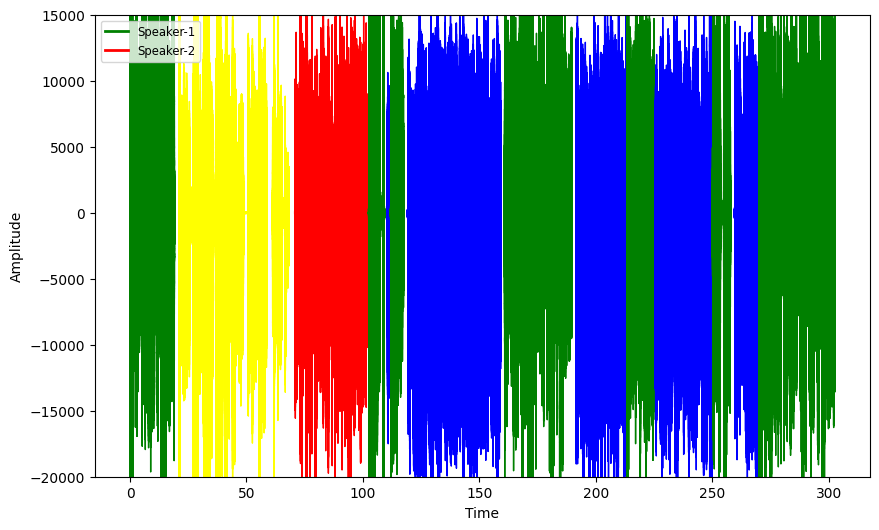

In [321]:
colors = {0:'green',1:'red',2:'blue',3:'yellow',4:'violet',5:'indigo',6:'orange'}

fs, data = wavfile.read(path)
time = np.arange(0, len(data)) / fs

plt.figure(figsize=(10,6))
for (i,segment) in enumerate(segments):
    plt.fill_between(time, data[0:], where=((time >= segment['start']) & (time <= segment['end'])), color=colors[labels[i]])

legend_handles = [plt.Line2D([0], [0], color='green', lw=2),
                  plt.Line2D([0], [0], color='red', lw=2),
                  ]

legend_labels = ["Speaker-"+str(i) for i in range(1,3)]

plt.ylim(-20000,15000)

plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.legend(legend_handles,legend_labels,fontsize="small",loc='upper left')

# Plot Points for all Audio Chunks

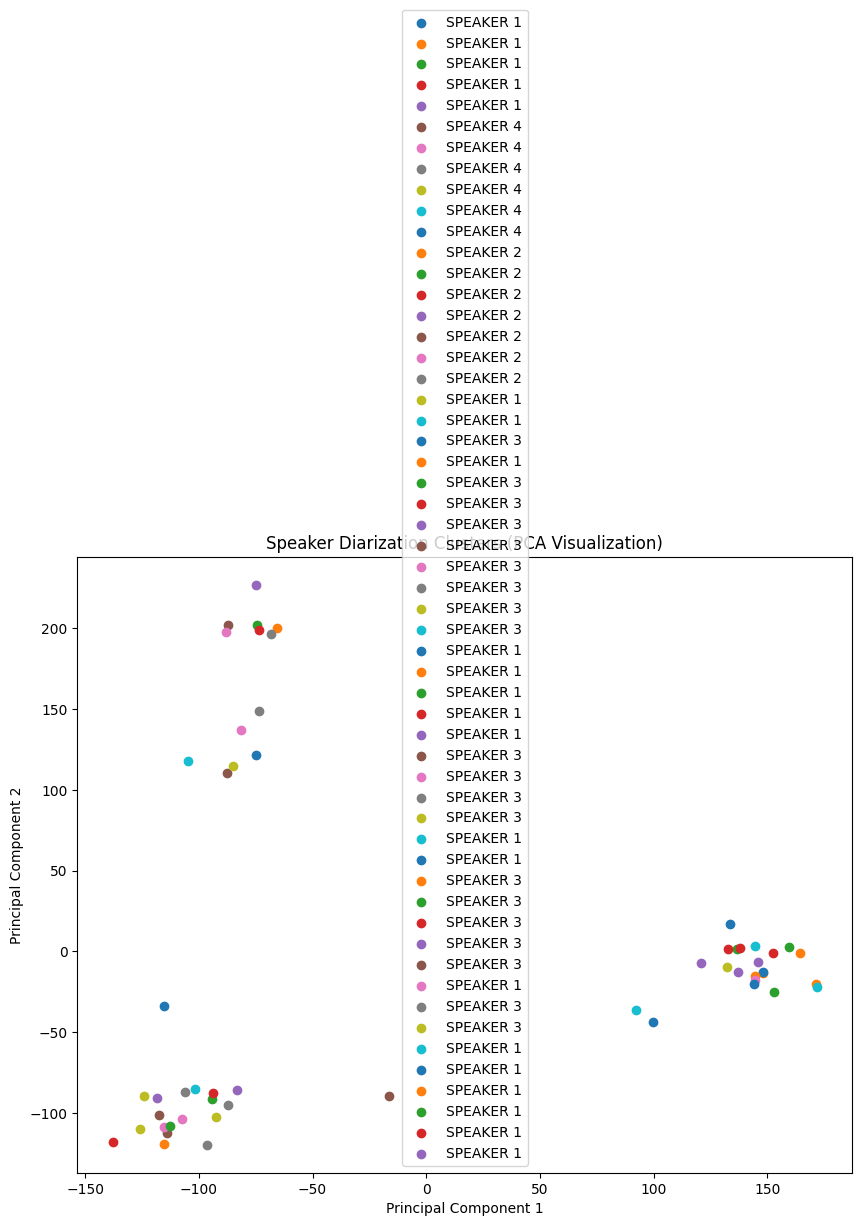

In [322]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# existing code for clustering and labeling segments...

# Perform PCA to reduce the dimensionality of embeddings to 2D
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

# Plot the clusters
plt.figure(figsize=(10, 8))
for i, segment in enumerate(segments):
    speaker_id = labels[i] + 1
    x, y = embeddings_2d[i]
    plt.scatter(x, y, label=f'SPEAKER {speaker_id}')

plt.title("Speaker Diarization Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# Audio Data Points at Right side of Graph is by Speaker 1 and Left side Graph is by Speaker 2

In [323]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# existing code for clustering and labeling segments...

# Perform PCA to reduce the dimensionality of embeddings to 3D
pca = PCA(n_components=3, random_state=42)
embeddings_3d = pca.fit_transform(embeddings)

# Get the number of unique speakers from the labels
num_unique_speakers = len(np.unique(labels))

# Create a colormap for speakers, ensuring each speaker gets a unique color
colors = cm.tab20b(np.linspace(0, 1, num_unique_speakers))

# Prepare the data for the 3D scatter plot
data = []
for i, segment in enumerate(segments):
    speaker_id = labels[i] + 1
    x, y, z = embeddings_3d[i]
    color = colors[labels[i] % num_unique_speakers]  # Get the corresponding color for the speaker
    trace = go.Scatter3d(x=[x], y=[y], z=[z], mode='markers',
                         marker=dict(size=5, color=color),
                         name=f'SPEAKER {speaker_id}')
    data.append(trace)

# Layout for the 3D scatter plot
layout = go.Layout(
    title="Speaker Diarization Clusters (3D Visualization)",
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    )
)

# Create the figure and plot the 3D scatter plot
fig = go.Figure(data=data, layout=layout)
fig.show()

# Sentiment Analysis Testing and Plotting

In [324]:
import sys
sys.path.append('../Utils')
from Models.sentiment_analysis import categorize_sentiment

pos = []
neg = []
neu = []
compound = []
sentiment = []
timestamp = []
speaker_labels = []

for (i,segment) in enumerate(segments):
    sentiment_category, sentiment_scores = categorize_sentiment(segment['text'])
    # print(sentiment_category,sentiment_scores,end="\n\n")
    speaker_labels.append(segment['speaker'])
    pos.append(sentiment_scores['pos'])
    neg.append(sentiment_scores['neg'])
    neu.append(sentiment_scores['neu'])
    compound.append(sentiment_scores['compound'])
    sentiment.append(sentiment_category)
    timestamp.append((segment['start'] + segment['end'])/2)

print(speaker_labels)
print(pos)
print(neg)
print(neu)
print(compound)
print(sentiment)
print(timestamp)

Score: {'neg': 0.0, 'neu': 0.769, 'pos': 0.231, 'compound': 0.3818}
Score: {'neg': 0.231, 'neu': 0.769, 'pos': 0.0, 'compound': -0.6369}
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Score: {'neg': 0.177, 'neu': 0.823, 'pos': 0.0, 'compound': -0.4215}
Score: {'neg': 0.266, 'neu': 0.734, 'pos': 0.0, 'compound': -0.7003}
Score: {'neg': 0.0, 'neu': 0.789, 'pos': 0.211, 'compound': 0.4939}
Score: {'neg': 0.113, 'neu': 0.75, 'pos': 0.137, 'compound': 0.1531}
Score: {'neg': 0.091, 'neu': 0.511, 'pos': 0.398, 'compound': 0.8126}
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Score: {'neg': 0.162, 'neu': 0.838, 'pos': 0.0, 'compound': -0.4019}
Score: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Score: {'neg': 0.146, 'neu': 0.854, 'pos': 0.0, 'compound': -0.4404}
Score: {'neg': 0.0, 'neu': 0.932, 'pos': 0.068, 'compound': 0.0258}
Score: 

## Sentiment scores vs timestamp

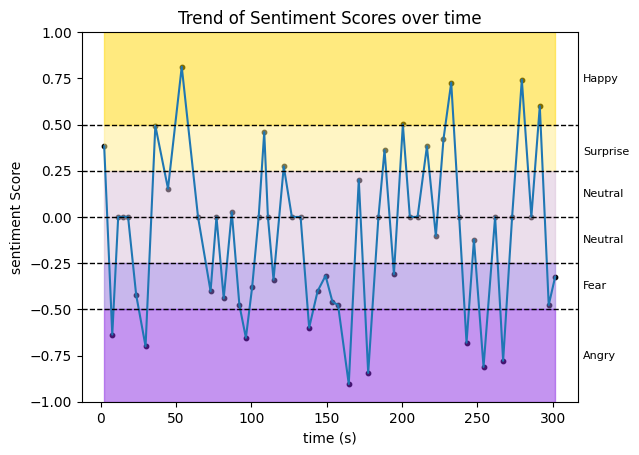

In [326]:
# plt.figure(figsize=(6,6))
plt.plot(timestamp, compound)
plt.yticks(np.arange(-1.0,1.0 + 0.25,0.25))
plt.ylim(-1.0,1.0)

sentiment_category_references_scores = [-0.5,-0.25,0.0,0.25,0.5]
sentiment_category_labels = ['Angry','Fear','Neutral','Neutral','Surprise','Happy']
sentiment_pos_offset = [-0.75,-0.375,-0.125,0.125,0.35,0.75]

for value in sentiment_category_references_scores:
    plt.axhline(y=value, color='black', linestyle='--', linewidth=1)

for i in range(len(sentiment_pos_offset)):
    plt.text(320, sentiment_pos_offset[i], sentiment_category_labels[i], color='black', fontsize=8, verticalalignment='center')

plt.scatter(timestamp,compound,color="black", s=10)

plt.fill_between(timestamp, 0.5, 1.0, color='#FFD700', alpha=0.5)
plt.fill_between(timestamp, 0.25, 0.5, color='#FFEC8B', alpha=0.5)
plt.fill_between(timestamp, 0, 0.25, color='#D8BFD8', alpha=0.5)
plt.fill_between(timestamp, 0, -0.25, color='#D8BFD8', alpha=0.5)
plt.fill_between(timestamp, -0.5, -0.25, color='#9370DB', alpha=0.5)
plt.fill_between(timestamp, -1.0, -0.5, color='#8A2BE2', alpha=0.5)

plt.xlabel('time (s)')
plt.ylabel('sentiment Score')
plt.title('Trend of Sentiment Scores over time')
plt.show()